"""
Mixed data structure and visualization
======================================

This example demonstrates how to build and visualize mixed datasets
containing both scalar and functional elements using the Canadian weather
dataset. In particular, we show how to include both a function and its
derivative, either jointly in a vector-valued functional object, or
separately as independent entries. We also explore how to structure and
visualize this data using `pandas` and scikit-fda’s visualization tools.
"""

# Author: Luis Hebrero Garicano
# License: MIT

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import skfda
from skfda import datasets
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.grid import FDataGrid


We load the Canadian weather dataset. This dataset includes daily
temperature and precipitation curves for 35 weather stations in Canada,
along with a scalar variable: the climate zone of each station.

In [2]:
X, y = datasets.fetch_weather(return_X_y=True, as_frame=True)
fd = X.iloc[:, 0].values
fd_temperatures = fd.coordinates[0]
fd_precipitations = fd.coordinates[1]

We visualize the two functional components separately.

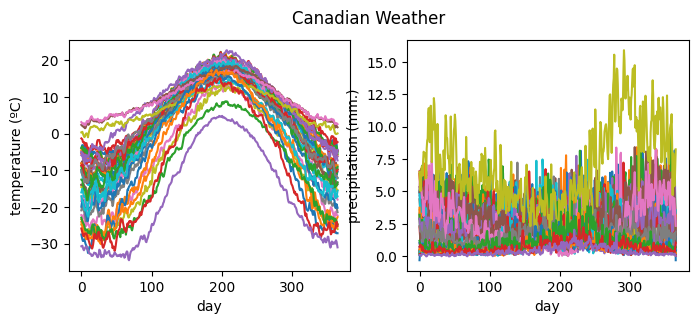

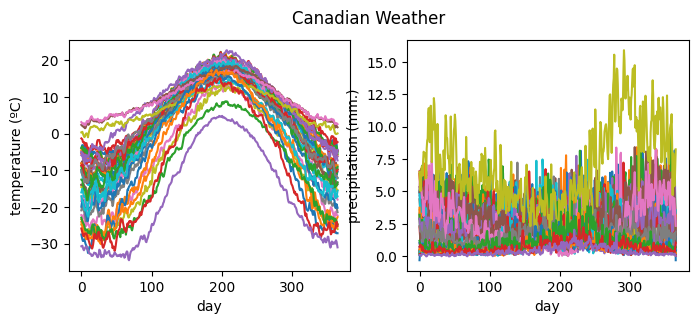

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

fd_temperatures.plot(axes= axes[0])
fd_precipitations.plot(axes = axes[1])

To enrich the data with dynamic information, we compute the first derivative
of both temperature and precipitation curves. These derivatives can capture
local variation patterns such as rising or falling trends.

In [4]:
fd_D_temperatures = fd_temperatures.derivative(order=1)
fd_D_precipitations = fd_precipitations.derivative(order=1)

Derivative curves often benefit from smoothing, especially when we plan to
use them in downstream tasks like clustering or regression.
We use Fourier basis representations with 5 elements for this purpose.

In [5]:
range_temperatures = (
    fd_temperatures.grid_points[0][0],
    fd_temperatures.grid_points[0][-1],
)
range_precipitations = (
    fd_precipitations.grid_points[0][0],
    fd_precipitations.grid_points[0][-1],
)

basis_temperatures = skfda.representation.basis.FourierBasis(
    range_temperatures, n_basis=5,
)
basis_precipitations = skfda.representation.basis.FourierBasis(
    range_precipitations, n_basis=5,
)

smoother_temperatures = BasisSmoother(basis=basis_temperatures)
smoother_precipitations = BasisSmoother(basis=basis_precipitations)


fd_D_temperatures_smooth = smoother_temperatures.fit_transform(fd_D_temperatures)
fd_D_precipitations_smooth = smoother_precipitations.fit_transform(fd_D_precipitations)



Let's take a look at the smoothed derivatives.

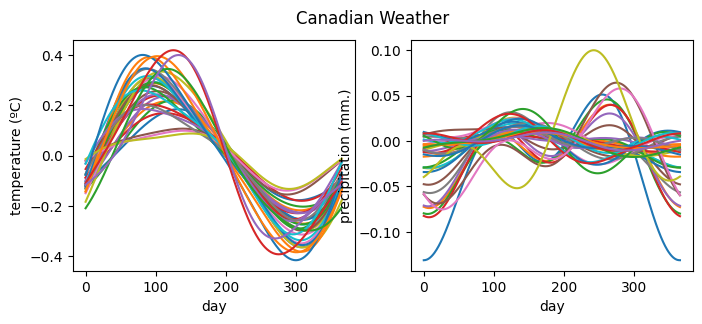

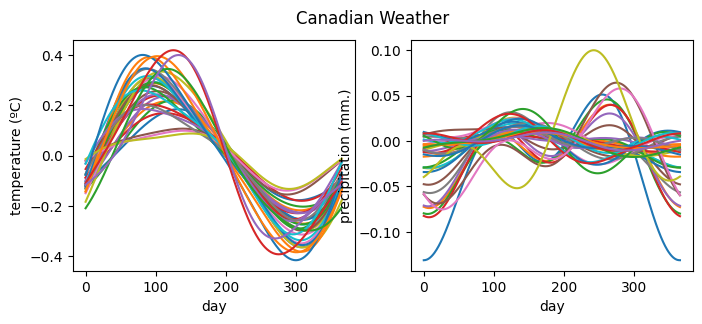

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

fd_D_temperatures_smooth.plot(axes= axes[0])
fd_D_precipitations_smooth.plot(axes= axes[1])

Now we build a vector-valued functional object that combines the original temperature and its derivative. This type of structure is useful when you want to treat them as a single feature with multiple components.

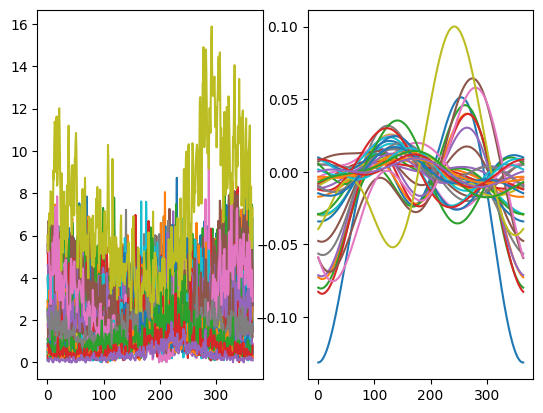

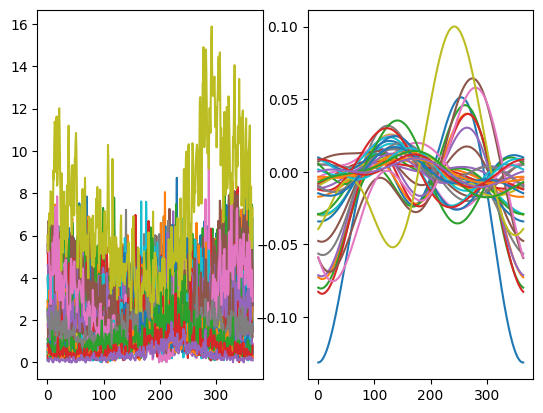

In [7]:

data_matrix = np.concatenate(
    [fd_precipitations.data_matrix, fd_D_precipitations_smooth.data_matrix],
    axis=2,
)

fd_vector = FDataGrid(
    data_matrix=data_matrix,
    grid_points=fd_temperatures.grid_points,
)

fd_vector.plot()

We now create a mixed data object using a `pandas.DataFrame`. This includes:
- a scalar variable: the climate zone,
- functional variables: the temperature and its derivative,
- and the vector-valued version combining both.

This illustrates two valid ways to include a function and its derivative
in mix

In [8]:
mixed_fd = pd.DataFrame(
    {
        "category": y,
        "temperatures": fd_temperatures,
        "temperature_derivatives": fd_D_temperatures_smooth,
        "precipitations_vector": fd_vector,
    },
)

Finally, we use `plot_mixed_data` to visualize the full mixed dataset. Each column is visualized with an appropriate method, helping us explore the structure and variation in both scalar and functional components.


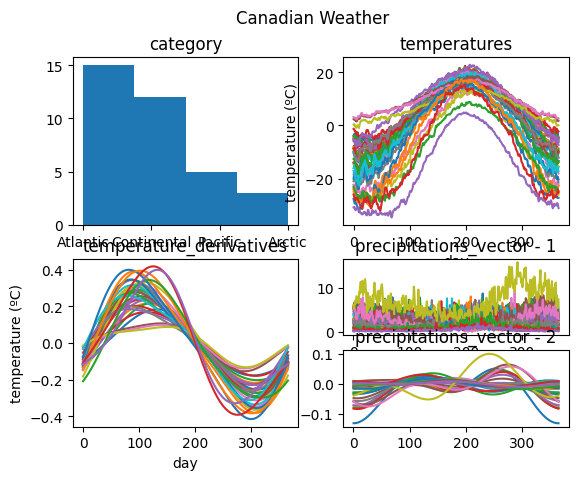

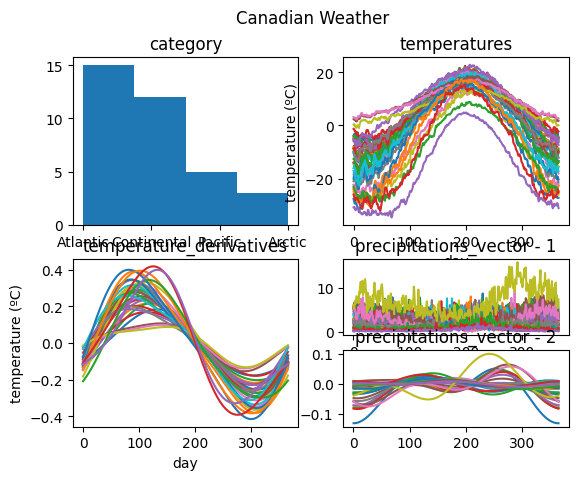

In [11]:
from skfda.exploratory.visualization.representation import plot_mixed_data
plot_mixed_data(mixed_fd)

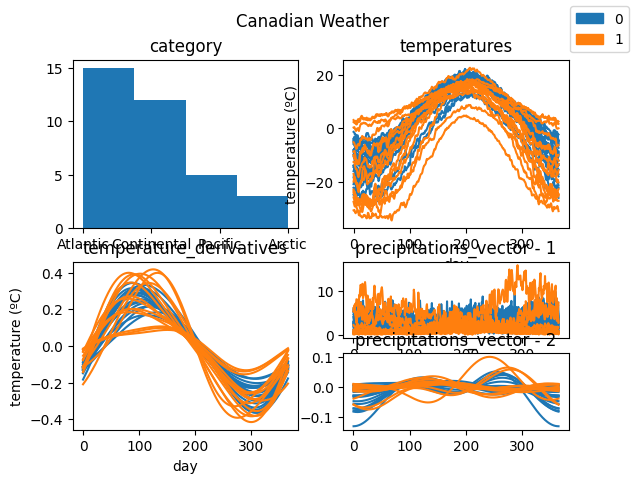

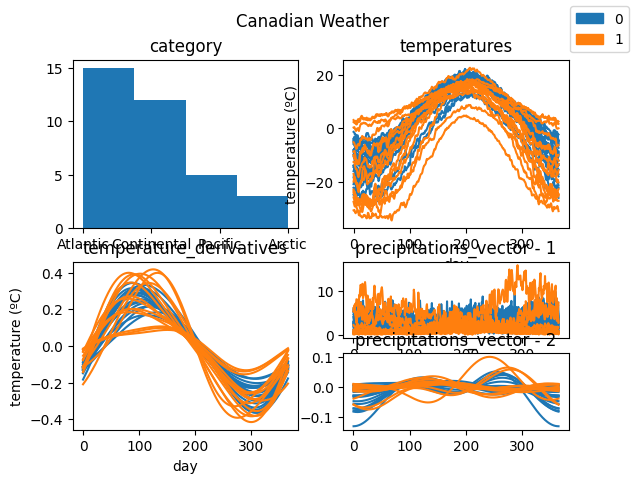

In [10]:
from skfda.exploratory.visualization.representation import plot_mixed_data
arr = np.array([0] * 20 + [1] * 15)
plot_mixed_data(mixed_fd, group=arr, legend=True)